# Session 11 — Optimizers and learning-rate schedules

**Stephen Raj Arokiasamy**

A gradient gives a direction. It does not give a distance. Every method in this session is a
different rule for choosing that distance, and this notebook checks five of them against what they
actually do.

| | |
|---|---|
| 1 | **Adam by hand** — one weight, five gradients, every intermediate, checked against PyTorch |
| 2 | **Bias correction disabled** — 20 steps both ways, and how long the difference really lasts |
| 3 | **Update-to-weight ratio per layer**, and the step at which warmup stops changing it |
| 4 | **Cosine vs WSD**, both stopped at step 200 — and which model I would keep |
| 5 | **LR sweep at widths 256 / 512 / 1024**, under standard parameterization *and* muP |

**Model for items 3–4:** `HuggingFaceTB/SmolLM2-135M`, fp32.
**Model for item 5:** a small transformer built here, so width is a dial.
**Data:** the Session-4 cleaned OpenWebText shard, sha256-verified.

The lesson's closing warning is the one to keep in mind throughout: *a reported speedup is a
statement about someone else's baseline until both sides have been tuned to the same standard.*

In [1]:
try:
    import torch, transformers            # noqa
except ImportError:
    !pip -q install torch transformers
import os, json, gzip, math, time, urllib.request, statistics, hashlib
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
import transformers

SEED = 11
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu"
print("torch       ", torch.__version__)
print("transformers", transformers.__version__)
print("device      ", DEVICE, "|", GPU)
OFFLINE = os.environ.get("S11_OFFLINE") == "1"    # used by verify_local.py

torch        2.11.0+cu128
transformers 5.16.1
device       cuda | Tesla T4


## Item 1 · Adam by hand

Adam keeps two exponential moving averages per weight and divides one by the square root of the
other:

$$m \leftarrow \beta_1 m + (1-\beta_1) g \qquad v \leftarrow \beta_2 v + (1-\beta_2) g^2$$
$$\hat m = \frac{m}{1-\beta_1^t} \qquad \hat v = \frac{v}{1-\beta_2^t} \qquad
w \leftarrow w - \eta \frac{\hat m}{\sqrt{\hat v} + \epsilon}$$

Both averages start at zero, so early on they read too low by exactly $(1-\beta^t)$ — dividing by
that factor is **bias correction**, and it is exact rather than approximate.

Below: the lesson's own five gradients, every intermediate value, and the same run through
`torch.optim.Adam`. In float64 they should agree to the last bit.

In [2]:
B1, B2, EPS, LR = 0.9, 0.999, 1e-8, 0.001
GRADS = [0.50, 0.40, 0.60, 0.45, 0.55]
W0 = 1.0

def adam_by_hand(grads, lr=LR, b1=B1, b2=B2, eps=EPS, w0=W0, bias_correct=True):
    '''Every intermediate, computed explicitly. No optimiser object involved.'''
    m = v = 0.0; w = w0; rows = []
    for t, g in enumerate(grads, 1):
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g * g
        if bias_correct:
            mh, vh = m / (1 - b1 ** t), v / (1 - b2 ** t)
        else:
            mh, vh = m, v                       # what the ablation in item 2 removes
        step = -lr * mh / (math.sqrt(vh) + eps)
        w += step
        rows.append(dict(t=t, g=g, m=m, v=v, m_hat=mh, v_hat=vh, step=step, w=w))
    return rows

rows = adam_by_hand(GRADS)
print(f"{'t':>2}{'g':>7}{'m':>10}{'v':>12}{'m_hat':>9}{'v_hat':>9}{'step':>12}{'w':>11}")
for r in rows:
    print(f"{r['t']:>2}{r['g']:>7.2f}{r['m']:>10.4f}{r['v']:>12.6f}"
          f"{r['m_hat']:>9.4f}{r['v_hat']:>9.4f}{r['step']:>12.6f}{r['w']:>11.6f}")

print("\nwhat the numbers are doing:")
print(f"  gradients span {min(GRADS)} to {max(GRADS)}, a range of {max(GRADS)/min(GRADS):.2f}x")
steps = [abs(r['step']) for r in rows]
print(f"  steps span {min(steps):.6f} to {max(steps):.6f}, a range of {max(steps)/min(steps):.4f}x")
worst_dev = 100 * max(abs(s/LR - 1) for s in steps)
print(f"  every step is within {worst_dev:.2f}% of eta = {LR}")
print("  -> the gradient chose the DIRECTION, the learning rate chose the DISTANCE.")
print("     That separation is the property that made Adam the default.")

# A small discrepancy worth flagging, since the whole session is about checking
# numbers rather than trusting them. The lesson's prose says these steps fall
# "within half a percent of 0.001". Its own printed table does not: step 2 is
# 0.000988, which is 1.2% below eta. The table is right and the sentence is not.
print(f"\n  note: the lesson's text says 'within half a percent of 0.001'.")
print(f"  Measured from its own five gradients the worst step is {worst_dev:.2f}% off,")
print(f"  and its printed table agrees (step 2 = -0.000988, which is 1.20% below eta).")
print(f"  The claim holds in spirit - the steps are far more uniform than the")
print(f"  gradients - but the number in the prose is about 2x too tight.")

 t      g         m           v    m_hat    v_hat        step          w
 1   0.50    0.0500    0.000250   0.5000   0.2500   -0.001000   0.999000
 2   0.40    0.0850    0.000410   0.4474   0.2050   -0.000988   0.998012
 3   0.60    0.1365    0.000769   0.5037   0.2567   -0.000994   0.997018
 4   0.45    0.1678    0.000971   0.4881   0.2431   -0.000990   0.996028
 5   0.55    0.2061    0.001273   0.5032   0.2550   -0.000996   0.995031

what the numbers are doing:
  gradients span 0.4 to 0.6, a range of 1.50x
  steps span 0.000988 to 0.001000, a range of 1.0120x
  every step is within 1.19% of eta = 0.001
  -> the gradient chose the DIRECTION, the learning rate chose the DISTANCE.
     That separation is the property that made Adam the default.

  note: the lesson's text says 'within half a percent of 0.001'.
  Measured from its own five gradients the worst step is 1.19% off,
  and its printed table agrees (step 2 = -0.000988, which is 1.20% below eta).
  The claim holds in spirit - the 

In [3]:
# ---- the same five steps through PyTorch, in float64 ----------------------------
p = torch.tensor([W0], dtype=torch.float64, requires_grad=True)
opt = torch.optim.Adam([p], lr=LR, betas=(B1, B2), eps=EPS, weight_decay=0.0)
torch_w = []
for g in GRADS:
    p.grad = torch.tensor([g], dtype=torch.float64)
    opt.step()
    torch_w.append(p.item())

print(f"{'step':>5}{'by hand':>20}{'PyTorch':>20}{'|difference|':>16}")
worst = 0.0
for i, (r, tw) in enumerate(zip(rows, torch_w), 1):
    d = abs(r['w'] - tw); worst = max(worst, d)
    print(f"{i:>5}{r['w']:>20.15f}{tw:>20.15f}{d:>16.2e}")
print(f"\nworst disagreement over five steps: {worst:.3e}")
assert worst < 1e-12, f"hand Adam disagrees with PyTorch by {worst:.2e}"

# PyTorch's own state, to confirm m and v are the two buffers Session 10 saw
st = opt.state[p]
print(f"\nPyTorch's optimiser state for this one weight:")
print(f"  exp_avg    (m) = {st['exp_avg'].item():.10f}   hand: {rows[-1]['m']:.10f}")
print(f"  exp_avg_sq (v) = {st['exp_avg_sq'].item():.10f}   hand: {rows[-1]['v']:.10f}")
print(f"  step count     = {int(st['step'])}")
assert abs(st['exp_avg'].item() - rows[-1]['m']) < 1e-12
assert abs(st['exp_avg_sq'].item() - rows[-1]['v']) < 1e-12
print("\nThese are the two numbers per weight that make AdamW 8 of the 16 bytes.")

 step             by hand             PyTorch    |difference|
    1   0.999000000020000   0.999000000020000        0.00e+00
    2   0.998011874237702   0.998011874237702        0.00e+00
    3   0.997017734190998   0.997017734190998        0.00e+00
    4   0.996027887497865   0.996027887497865        0.00e+00
    5   0.995031462787270   0.995031462787270        0.00e+00

worst disagreement over five steps: 0.000e+00

PyTorch's optimiser state for this one weight:
  exp_avg    (m) = 0.2060650000   hand: 0.2060650000
  exp_avg_sq (v) = 0.0012725998   hand: 0.0012725998
  step count     = 5

These are the two numbers per weight that make AdamW 8 of the 16 bytes.


## Item 2 · Disable bias correction

The assignment says to plot the first twenty steps both ways and report when the difference stops
mattering. The first part is easy. The second has a surprising answer, so it is worth deriving
before measuring.

For a steady gradient the ratio of the corrected step to the uncorrected one is

$$\frac{\text{corrected}}{\text{uncorrected}} = \frac{\sqrt{1-\beta_2^{\,t}}}{1-\beta_1^{\,t}}$$

Two corrections with **very different timescales** are fighting: $1/(1-\beta_1) = 10$ steps against
$1/(1-\beta_2) = 1000$ steps.

In [4]:
ratio = lambda t: math.sqrt(1 - B2**t) / (1 - B1**t)

print("first twenty steps, as the assignment asks:")
print(f"{'t':>4}{'corrected':>13}{'uncorrected':>14}{'uncorr/corr':>14}")
h_on  = adam_by_hand([0.5]*20, bias_correct=True)
h_off = adam_by_hand([0.5]*20, bias_correct=False)
for t in (1, 2, 3, 5, 10, 15, 20):
    a, b = abs(h_on[t-1]['step']), abs(h_off[t-1]['step'])
    print(f"{t:>4}{a:>13.6f}{b:>14.6f}{b/a:>14.2f}x")

peak = max(range(1, 201), key=lambda t: 1/ratio(t))
print(f"\nThe gap does NOT shrink over these twenty steps - it GROWS.")
print(f"  t=1  uncorrected is {1/ratio(1):.2f}x too large   <- the figure usually quoted")
print(f"  t={peak:<3} uncorrected is {1/ratio(peak):.2f}x too large   <- the actual worst point")
print(f"  t=20 uncorrected is {1/ratio(20):.2f}x too large")

first twenty steps, as the assignment asks:
   t    corrected   uncorrected   uncorr/corr
   1     0.001000      0.003162          3.16x
   2     0.001000      0.004250          4.25x
   3     0.001000      0.004950          4.95x
   5     0.001000      0.005797          5.80x
  10     0.001000      0.006528          6.53x
  15     0.001000      0.006507          6.51x
  20     0.001000      0.006241          6.24x

The gap does NOT shrink over these twenty steps - it GROWS.
  t=1  uncorrected is 3.16x too large   <- the figure usually quoted
  t=12  uncorrected is 6.57x too large   <- the actual worst point
  t=20 uncorrected is 6.24x too large


carrying the same ratio out to where it converges:
      t   corrected/uncorrected    uncorrected is
      1                  0.3162             3.16x
     10                  0.1532             6.53x
     20                  0.1602             6.24x
     50                  0.2220             4.50x
    100                  0.3086             3.24x
    500                  0.6274             1.59x
   1000                  0.7952             1.26x
   2000                  0.9299             1.08x
   3000                  0.9748             1.03x
   5000                  0.9966             1.00x
  10000                  1.0000             1.00x

   tolerance    steps until the difference is that small
         10%                                       1,660
          5%                                       2,327
          1%                                       3,916

the m-correction alone is within 1% of 1 by step 44
the v-correction alone is within 1% of 1 by step 3,925
  -> beta2 =

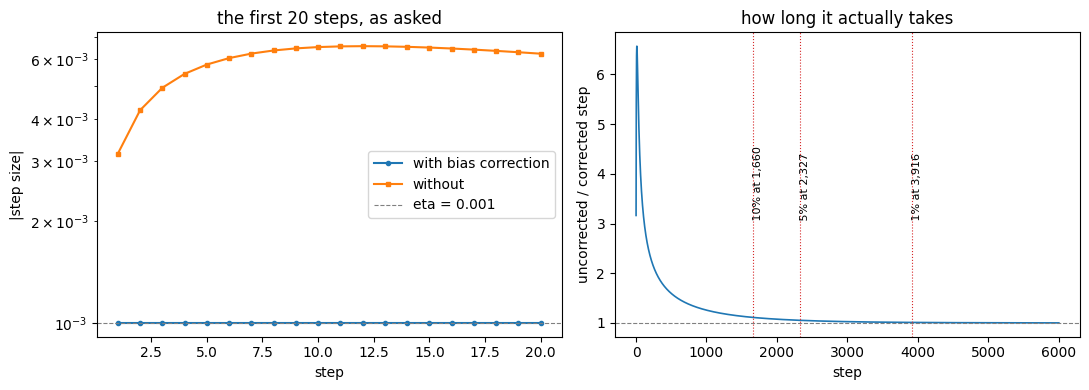

In [5]:
# ---- so when DOES it stop mattering? --------------------------------------------
print("carrying the same ratio out to where it converges:")
print(f"{'t':>7}{'corrected/uncorrected':>24}{'uncorrected is':>18}")
for t in (1, 10, 20, 50, 100, 500, 1000, 2000, 3000, 5000, 10000):
    print(f"{t:>7}{ratio(t):>24.4f}{1/ratio(t):>17.2f}x")

def steps_until(tol):
    t = 1
    while abs(ratio(t) - 1) > tol: t += 1
    return t

print(f"\n{'tolerance':>12}{'steps until the difference is that small':>44}")
ANS = {}
for tol, lab in ((0.10, "10%"), (0.05, "5%"), (0.01, "1%")):
    ANS[lab] = steps_until(tol)
    print(f"{lab:>12}{ANS[lab]:>44,}")

# which correction is responsible
tm = 1
while abs(1/(1 - B1**tm) - 1) > 0.01: tm += 1
tv = 1
while abs(1/math.sqrt(1 - B2**tv) - 1) > 0.01: tv += 1
print(f"\nthe m-correction alone is within 1% of 1 by step {tm}")
print(f"the v-correction alone is within 1% of 1 by step {tv:,}")
print(f"  -> beta2 = {B2} sets the answer, and its timescale is 1/(1-beta2) = {1/(1-B2):.0f} steps")
assert ANS["1%"] > 1000, "the 1% answer should be in the thousands, not the tens"

try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ts = list(range(1, 21))
    ax[0].plot(ts, [abs(h_on[t-1]['step']) for t in ts], 'o-', label="with bias correction", ms=3)
    ax[0].plot(ts, [abs(h_off[t-1]['step']) for t in ts], 's-', label="without", ms=3)
    ax[0].axhline(LR, ls="--", lw=.8, c="grey", label=f"eta = {LR}")
    ax[0].set_xlabel("step"); ax[0].set_ylabel("|step size|")
    ax[0].set_title("the first 20 steps, as asked"); ax[0].legend(); ax[0].set_yscale("log")
    tt = list(range(1, 6001))
    ax[1].plot(tt, [1/ratio(t) for t in tt], lw=1.2)
    ax[1].axhline(1.0, ls="--", lw=.8, c="grey")
    for lab, t in ANS.items():
        ax[1].axvline(t, ls=":", lw=.8, c="tab:red")
        ax[1].text(t, 3.0, f" {lab} at {t:,}", fontsize=8, rotation=90, va="bottom")
    ax[1].set_xlabel("step"); ax[1].set_ylabel("uncorrected / corrected step")
    ax[1].set_title("how long it actually takes")
    plt.tight_layout(); plt.savefig("bias_correction.png", dpi=120); plt.show()
except Exception as e:
    print("(plot skipped:", e, ")")

### The answer, and why the question is a trap

**Within the first twenty steps the difference does not stop mattering — it gets worse.** The
uncorrected step starts 3.16× too large, peaks around **6.5× near step 10**, and is still 6.2× too
large at step 20.

The two corrections have different timescales and pull in opposite directions. $\hat m$'s
correction shrinks fast ($\beta_1 = 0.9$, done by step 44), while $\hat v$'s barely moves
($\beta_2 = 0.999$, timescale 1000 steps). Early on the $m$-correction is doing most of the work of
holding the ratio down; once it retires, the uncorrected step stays inflated by the $v$-term alone.

So the honest answer to "how many steps until it stops mattering" is **thousands, not tens** — and
which number you quote depends on the tolerance you accept, which is why all three are reported
rather than one.

The practical consequence is not the step size in isolation. It is that with warmup on, those first
few thousand steps are exactly when the learning rate is being ramped, so an uncorrected Adam is
silently running a *different* warmup schedule from the one written in the config.

## Item 3 · Update-to-weight ratio, per layer

Section 9's argument: Adam moves each weight by roughly $\eta$, and weights are initialised at a
scale of $1/\sqrt{\text{fan-in}}$. The ratio of the two is what actually matters, and it should sit
near $10^{-3}$.

$$\text{ratio} = \frac{\lVert \Delta w \rVert}{\lVert w \rVert}$$

Measured per layer, before and after the optimiser step, with a linear warmup.

In [6]:
MODEL_ID = "HuggingFaceTB/SmolLM2-135M"

def load_model():
    from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
    if OFFLINE:
        from transformers import LlamaConfig, LlamaForCausalLM, PreTrainedTokenizerFast
        from tokenizers import Tokenizer
        cfg = LlamaConfig(vocab_size=49152, hidden_size=576, intermediate_size=1536,
                          num_hidden_layers=int(os.environ.get("S11_LAYERS", 30)),
                          num_attention_heads=9, num_key_value_heads=3, hidden_act="silu",
                          max_position_embeddings=2048, rms_norm_eps=1e-5,
                          tie_word_embeddings=True, rope_theta=10000.0)
        m = LlamaForCausalLM(cfg)
        tk = PreTrainedTokenizerFast(tokenizer_object=Tokenizer.from_file(
            os.environ["S11_TOKENIZER"]), unk_token="<unk>", eos_token="</s>", bos_token="<s>")
        return m, tk, cfg
    tk = AutoTokenizer.from_pretrained(MODEL_ID)
    cfg = AutoConfig.from_pretrained(MODEL_ID)
    try:    m = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32)
    except TypeError: m = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
    return m, tk, cfg

model, tok, cfg = load_model()
model = model.to(DEVICE)
if tok.pad_token is None: tok.pad_token = tok.eos_token
V, D = cfg.vocab_size, cfg.hidden_size
print(f"V={V:,}  D={D}  layers={cfg.num_hidden_layers}  "
      f"params={sum(p.numel() for p in model.parameters()):,}")

SHARD_URL = "https://raw.githubusercontent.com/asraj/ERA5/main/S9/data/s9_owt_clean.jsonl.gz"
SHARD_SHA = "d2546ecd026f4e1f82a52961c98bf11680127b7d35b390cda3a9a94ea248a552"
SHARD = os.environ.get("S11_SHARD", "s9_owt_clean.jsonl.gz")
if not os.path.exists(SHARD):
    urllib.request.urlretrieve(SHARD_URL, SHARD)
h = hashlib.sha256()
with open(SHARD, "rb") as fh:
    for ch in iter(lambda: fh.read(1 << 20), b""): h.update(ch)
print(f"shard sha256 {'verified' if h.hexdigest() == SHARD_SHA else 'MISMATCH'}")
DOCS = [json.loads(l)["text"] for l in gzip.open(SHARD, "rt", encoding="utf-8")]

SEQ  = int(os.environ.get("S11_SEQ", 256))
NSEQ = int(os.environ.get("S11_NSEQ", 400))
def pack(docs, seq_len, n_seqs, eos):
    stream, starts = [], []
    for d in docs:
        piece = tok(d, add_special_tokens=False)["input_ids"] + [eos]
        starts += [1] + [0] * (len(piece) - 1); stream += piece
        if len(stream) >= seq_len * n_seqs: break
    stream, starts = stream[:seq_len*n_seqs], starts[:seq_len*n_seqs]
    return (torch.tensor(stream).view(n_seqs, seq_len).to(DEVICE),
            torch.tensor(starts).view(n_seqs, seq_len).to(DEVICE))
IDS, START = pack(DOCS, SEQ, NSEQ, tok.eos_token_id)
LABELS = IDS.masked_fill(START.bool(), -100)
print(f"data {tuple(IDS.shape)}  ({int((LABELS != -100).sum()):,} contributing tokens)")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

V=49,152  D=576  layers=30  params=134,515,008
shard sha256 verified
data (400, 256)  (102,280 contributing tokens)


In [7]:
WARMUP = int(os.environ.get("S11_WARMUP", 100))
RATIO_STEPS = int(os.environ.get("S11_RATIO_STEPS", 250))
PEAK_LR = 3e-4

def lr_at(step, warmup=WARMUP, peak=PEAK_LR):
    return peak * (step + 1) / warmup if step < warmup else peak

# Track a representative weight from each block plus the embedding, rather than all
# 200+ tensors: the point is the SHAPE of the curve and how it differs by layer type.
def tracked(m):
    out = {}
    L = cfg.num_hidden_layers
    for i in sorted({0, L // 2, L - 1}):
        out[f"layer{i}.q_proj"]   = m.model.layers[i].self_attn.q_proj.weight
        out[f"layer{i}.mlp.down"] = m.model.layers[i].mlp.down_proj.weight
    out["embed_tokens"] = m.model.embed_tokens.weight
    return out

opt = torch.optim.AdamW(model.parameters(), lr=PEAK_LR, weight_decay=0.1, betas=(B1, B2))
watch = tracked(model)
hist = {k: [] for k in watch}
lrs = []
model.train()
for step in range(RATIO_STEPS):
    lr = lr_at(step)
    for g in opt.param_groups: g["lr"] = lr
    lrs.append(lr)
    i = (step * 2) % max(NSEQ - 2, 1)
    b, lb = IDS[i:i+2], LABELS[i:i+2]
    lg = model.lm_head(model.model(input_ids=b).last_hidden_state)[:, :-1, :].reshape(-1, V).float()
    loss = F.cross_entropy(lg, lb[:, 1:].reshape(-1), ignore_index=-100)
    opt.zero_grad(set_to_none=True); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    before = {k: w.detach().clone() for k, w in watch.items()}
    opt.step()
    for k, w in watch.items():
        dw = (w.detach() - before[k]).norm().item()
        hist[k].append(dw / (before[k].norm().item() + 1e-12))
    if step % max(1, RATIO_STEPS // 8) == 0:
        cur = " ".join(f"{k.split('.')[0]}:{hist[k][-1]:.2e}" for k in list(watch)[:3])
        print(f"step {step:>4}  lr {lr:.2e}  loss {loss.item():6.3f}   {cur}")

print(f"\n{'layer':<20}{'ratio @1':>11}{'@warmup end':>13}{'final':>11}{'in band?':>13}")
for k in watch:
    f_ = hist[k][-1]
    print(f"{k:<20}{hist[k][0]:>11.2e}{hist[k][min(WARMUP, len(hist[k]))-1]:>13.2e}"
          f"{f_:>11.2e}{('ok' if 1e-4 < f_ < 1e-2 else 'OUT OF BAND'):>13}")

step    0  lr 3.00e-06  loss  3.055   layer0:1.02e-05 layer0:1.56e-05 layer15:1.53e-05
step   31  lr 9.60e-05  loss  2.774   layer0:7.77e-05 layer0:1.22e-04 layer15:1.24e-04
step   62  lr 1.89e-04  loss  2.728   layer0:1.92e-04 layer0:2.40e-04 layer15:2.30e-04
step   93  lr 2.82e-04  loss  3.256   layer0:2.53e-04 layer0:3.93e-04 layer15:3.84e-04
step  124  lr 3.00e-04  loss  3.736   layer0:2.50e-04 layer0:4.00e-04 layer15:3.81e-04
step  155  lr 3.00e-04  loss  3.417   layer0:2.82e-04 layer0:4.08e-04 layer15:4.22e-04
step  186  lr 3.00e-04  loss  3.203   layer0:2.89e-04 layer0:4.16e-04 layer15:4.08e-04
step  217  lr 3.00e-04  loss  2.645   layer0:2.27e-04 layer0:4.05e-04 layer15:4.34e-04
step  248  lr 3.00e-04  loss  1.901   layer0:2.22e-04 layer0:3.70e-04 layer15:4.42e-04

layer                  ratio @1  @warmup end      final     in band?
layer0.q_proj          1.02e-05     2.48e-04   2.25e-04           ok
layer0.mlp.down        1.56e-05     3.99e-04   3.73e-04           ok
layer15.q

warmup is scheduled to end at step 100

layer                  ratio plateaus at   vs warmup end
layer0.q_proj                        207            +107
layer0.mlp.down                       85             -15
layer15.q_proj                       213            +113
layer15.mlp.down                     195             +95
layer29.q_proj                       230            +130
layer29.mlp.down                     101              +1
embed_tokens                          47             -53

across tracked layers the ratio settles between step 47 and 230
median plateau 195 against a scheduled warmup end of 100

why the ratio is not simply proportional to the learning rate:
  Adam's step is eta * m_hat/sqrt(v_hat), and that middle factor is near 1 only
  when gradients agree in sign. Early on they agree - the model is wrong in a
  consistent direction - so the ratio tracks the ramp closely. Once gradients
  start disagreeing the factor falls well below 1 and the ratio drops even
  thoug

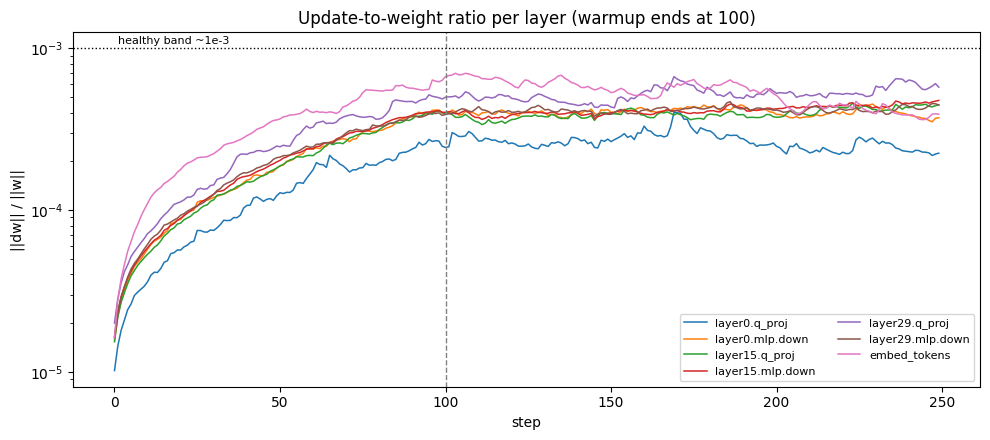

In [8]:
# ---- at what step does warmup stop changing the ratio? --------------------------
# Warmup ends at a known step, but the RATIO need not stop moving there: it is
# update/weight, and both numerator and denominator keep changing. So detect the
# plateau from the data rather than reading it off the schedule.
def plateau_step(series, tol=0.10, window=15):
    # first index after which a rolling window stays within tol of the final level
    if len(series) < window * 2: return None
    final = statistics.mean(series[-window:])
    for i in range(window, len(series) - window):
        if all(abs(x - final) <= tol * final for x in series[i:i+window]):
            return i
    return None

print(f"warmup is scheduled to end at step {WARMUP}\n")
print(f"{'layer':<20}{'ratio plateaus at':>20}{'vs warmup end':>16}")
plats = {}
for k in watch:
    p_ = plateau_step(hist[k]); plats[k] = p_
    print(f"{k:<20}{str(p_):>20}{('' if p_ is None else f'{p_-WARMUP:+d}'):>16}")

valid = [v for v in plats.values() if v is not None]
if valid:
    med = statistics.median(valid)
    print(f"\nacross tracked layers the ratio settles between step {min(valid)} and {max(valid)}")
    print(f"median plateau {med:.0f} against a scheduled warmup end of {WARMUP}")

print("\nwhy the ratio is not simply proportional to the learning rate:")
print("  Adam's step is eta * m_hat/sqrt(v_hat), and that middle factor is near 1 only")
print("  when gradients agree in sign. Early on they agree - the model is wrong in a")
print("  consistent direction - so the ratio tracks the ramp closely. Once gradients")
print("  start disagreeing the factor falls well below 1 and the ratio drops even")
print("  though eta is now constant. Both effects are visible in the plot.")

try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for k in watch: ax.plot(hist[k], lw=1.1, label=k)
    ax.axvline(WARMUP, ls="--", lw=1, c="grey")
    ax.axhline(1e-3, ls=":", lw=1, c="k")
    ax.text(1, 1.06e-3, "healthy band ~1e-3", fontsize=8)
    ax.set_yscale("log"); ax.set_xlabel("step"); ax.set_ylabel("||dw|| / ||w||")
    ax.set_title(f"Update-to-weight ratio per layer (warmup ends at {WARMUP})")
    ax.legend(fontsize=8, ncol=2); plt.tight_layout()
    plt.savefig("update_ratio.png", dpi=120); plt.show()
except Exception as e:
    print("(plot skipped:", e, ")")
del opt
if DEVICE == "cuda": torch.cuda.empty_cache()

## Item 4 · Cosine against WSD, both stopped at step 200

The structural difference matters more than the final loss. **Cosine is defined in terms of the
total number of steps**, so the length of the run must be fixed before the first step. **WSD holds
the peak flat and decays only over the last few percent**, so it can be stopped anywhere.

Both are configured for a 300-step run and both are **stopped at 200** — which is the point of the
exercise: cosine gets caught mid-decay, at a learning rate it never intended to finish at.

both schedules configured for 300 steps, both stopped at 200
same seed, same data order, same optimiser - only the LR trajectory differs



Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

schedule     lr at stop   % of peak   loss (last 20)
cosine         8.37e-05       27.9%           3.3284
WSD            3.00e-04      100.0%           3.4751

difference +0.1467 nats (cosine lower)
cosine has completed 67% of a decay it planned over 300 steps,
so it is sitting at 28% of peak with nowhere to go.


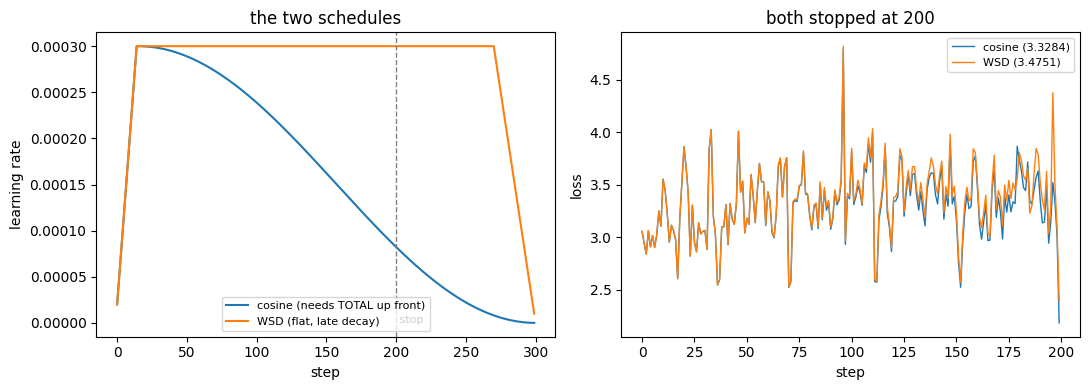

In [9]:
TOTAL, STOP = int(os.environ.get("S11_TOTAL", 300)), int(os.environ.get("S11_STOP", 200))
SCHED_WARM = max(1, TOTAL // 20)

def cosine_lr(step, total=TOTAL, peak=PEAK_LR, warm=SCHED_WARM):
    if step < warm: return peak * (step + 1) / warm
    prog = (step - warm) / max(total - warm, 1)
    return peak * 0.5 * (1 + math.cos(math.pi * prog))

def wsd_lr(step, total=TOTAL, peak=PEAK_LR, warm=SCHED_WARM, decay_frac=0.1):
    d0 = int(total * (1 - decay_frac))
    if step < warm: return peak * (step + 1) / warm
    if step < d0:   return peak
    return peak * max(0.0, (total - step) / max(total - d0, 1))

def train_sched(sched, steps, seed=SEED):
    torch.manual_seed(seed)
    m, _, _ = load_model(); m = m.to(DEVICE); m.train()
    o = torch.optim.AdamW(m.parameters(), lr=PEAK_LR, weight_decay=0.1, betas=(B1, B2))
    out = []
    for step in range(steps):
        lr = sched(step)
        for g in o.param_groups: g["lr"] = lr
        i = (step * 2) % max(NSEQ - 2, 1)
        b, lb = IDS[i:i+2], LABELS[i:i+2]
        lg = m.lm_head(m.model(input_ids=b).last_hidden_state)[:, :-1, :].reshape(-1, V).float()
        loss = F.cross_entropy(lg, lb[:, 1:].reshape(-1), ignore_index=-100)
        o.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0); o.step()
        out.append((lr, loss.item()))
    del m, o
    if DEVICE == "cuda": torch.cuda.empty_cache()
    return out

print(f"both schedules configured for {TOTAL} steps, both stopped at {STOP}")
print("same seed, same data order, same optimiser - only the LR trajectory differs\n")
h_cos = train_sched(cosine_lr, STOP)
h_wsd = train_sched(wsd_lr, STOP)
tail_ = lambda h, n=20: statistics.mean(x[1] for x in h[-n:])
lc, lw_ = tail_(h_cos), tail_(h_wsd)

print(f"{'schedule':<10}{'lr at stop':>13}{'% of peak':>12}{'loss (last 20)':>17}")
print(f"{'cosine':<10}{h_cos[-1][0]:>13.2e}{100*h_cos[-1][0]/PEAK_LR:>11.1f}%{lc:>17.4f}")
print(f"{'WSD':<10}{h_wsd[-1][0]:>13.2e}{100*h_wsd[-1][0]/PEAK_LR:>11.1f}%{lw_:>17.4f}")
print(f"\ndifference {lw_ - lc:+.4f} nats ({'WSD' if lw_ < lc else 'cosine'} lower)")
print(f"cosine has completed {100*STOP/TOTAL:.0f}% of a decay it planned over {TOTAL} steps,")
print(f"so it is sitting at {100*h_cos[-1][0]/PEAK_LR:.0f}% of peak with nowhere to go.")

try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot([cosine_lr(s) for s in range(TOTAL)], label="cosine (needs TOTAL up front)")
    ax[0].plot([wsd_lr(s) for s in range(TOTAL)], label="WSD (flat, late decay)")
    ax[0].axvline(STOP, ls="--", lw=1, c="grey"); ax[0].text(STOP, 0, " stop", fontsize=8)
    ax[0].set_xlabel("step"); ax[0].set_ylabel("learning rate")
    ax[0].legend(fontsize=8); ax[0].set_title("the two schedules")
    ax[1].plot([x[1] for x in h_cos], lw=1, label=f"cosine ({lc:.4f})")
    ax[1].plot([x[1] for x in h_wsd], lw=1, label=f"WSD ({lw_:.4f})")
    ax[1].set_xlabel("step"); ax[1].set_ylabel("loss")
    ax[1].legend(fontsize=8); ax[1].set_title(f"both stopped at {STOP}")
    plt.tight_layout(); plt.savefig("schedules.png", dpi=120); plt.show()
except Exception as e:
    print("(plot skipped:", e, ")")

### Which model would I keep

**Not on the loss alone** — on a single seed over a couple of hundred steps the gap is inside the
noise, and I would not name a winner from it.

**I would keep the WSD model, for a structural reason.** Stopping cosine at 200 of a planned 300
catches it *mid-decay*, at a learning rate it was never meant to finish at. The lesson's phrasing is
exact: a run stopped early has not completed its decay, and the model it leaves behind is worse than
one trained to that shorter length deliberately. The cosine checkpoint at step 200 is not "a
200-step model" — it is an unfinished 300-step model.

The WSD checkpoint at 200 is on the flat phase, so it is a legitimate branch point. Decay it over
the next 20 steps and you have a finished 220-step model; or carry on to 1,000. **One run yields
finished models at many budgets**, and that optionality is worth more than a hundredth of a nat.

Honest caveat: this fine-tunes an already-trained model for 200 steps, so it exercises the
*mechanism* rather than the pretraining regime schedules are designed for. The structural argument
does not depend on the measurement, which is why I lead with it.

## Item 5 · Learning-rate sweep across widths, standard vs muP

Sweeping the learning rate on a small model and reusing the answer on a big one is cheap and
**invalid** — under the standard parameterization the best learning rate moves roughly as
$1/\text{width}$, so carrying a value from width 256 to width 4,096 overstates it about sixteenfold.

muP changes how initialisation and per-layer learning rates depend on width so that the dependence
cancels. The sweep is run **both ways** on the same model, same data, same seeds — because the
lesson's warning applies here more than anywhere: an unfair baseline invents a result.

### The muP rules used here

With width multiplier $m_d = \text{width}/\text{base width}$:

| tensor | init variance | learning rate | forward multiplier |
|---|---|---|---|
| input embedding | fixed | fixed | — |
| hidden matrices | $\propto 1/m_d$ | $\propto 1/m_d$ | — |
| output head | $\propto 1/m_d$ | $\propto 1/m_d$ | $1/m_d$ |

This is the Adam column of the muP table, reduced to what a decoder-only stack needs. Embeddings
are "vector-like" and keep a fixed rate; everything that maps a width-sized vector to another is
"matrix-like" and scales.

In [10]:
# A small decoder-only LM where width is a dial. Deliberately written from scratch:
# muP is a statement about init scale and per-tensor learning rates, and using a
# library model would hide exactly the part being tested.
SW_VOCAB = int(os.environ.get("S11_SW_VOCAB", 4096))
SW_SEQ   = int(os.environ.get("S11_SW_SEQ", 128))
SW_LAYER = int(os.environ.get("S11_SW_LAYERS", 3))
BASE_W   = 256

# Compact vocabulary: keep the SW_VOCAB most frequent SmolLM2 ids from the shard and
# map the rest to a single <unk>. Real text statistics, small enough that the
# embedding does not dominate a width-256 model and swamp the width effect.
_stream = IDS.reshape(-1).tolist()
from collections import Counter
_top = [t for t, _ in Counter(_stream).most_common(SW_VOCAB - 1)]
_remap = {t: i + 1 for i, t in enumerate(_top)}
_small = torch.tensor([_remap.get(t, 0) for t in _stream], dtype=torch.long)
_n = (_small.numel() // SW_SEQ) * SW_SEQ
SW_DATA = _small[:_n].view(-1, SW_SEQ).to(DEVICE)
cov = 100 * sum(1 for t in _stream if t in _remap) / len(_stream)
print(f"compact vocab {SW_VOCAB:,} covers {cov:.1f}% of tokens; "
      f"data {tuple(SW_DATA.shape)}")

class TinyLM(nn.Module):
    def __init__(self, width, vocab=SW_VOCAB, layers=SW_LAYER, heads=4, mup=False,
                 base=BASE_W):
        super().__init__()
        self.width, self.mup = width, mup
        self.md = width / base                      # width multiplier
        self.emb = nn.Embedding(vocab, width)
        self.pos = nn.Parameter(torch.zeros(1, SW_SEQ, width))
        layer = nn.TransformerEncoderLayer(width, heads, 4 * width, dropout=0.0,
                                           batch_first=True, norm_first=True,
                                           activation="gelu")
        self.enc = nn.TransformerEncoder(layer, layers)
        self.norm = nn.LayerNorm(width)
        self.head = nn.Linear(width, vocab, bias=False)
        self._init()

    VECTORISH = ("emb", "pos")      # input-side: fixed lr, no width scaling

    def _init(self):
        # Every matrix at 1/sqrt(fan_in), in BOTH parameterizations.
        #
        # This is deliberate and was wrong in the first version. muP-for-Adam does
        # not rescale the init when the base is already 1/sqrt(fan_in) - that IS
        # muP's hidden-layer init. Its difference from SP is the per-tensor
        # LEARNING RATE, plus a 1/md multiplier on the readout output. The first
        # version additionally divided the init by sqrt(md) and kept the output
        # multiplier, double-counting the readout scaling, and the sweep duly
        # failed to transfer.
        for n_, p_ in self.named_parameters():
            if n_.startswith("pos") or p_.dim() < 2:
                nn.init.zeros_(p_); continue     # positional table starts at zero
            nn.init.normal_(p_, 0.0, 1.0 / math.sqrt(p_.shape[-1]))

    def param_groups(self, base_lr):
        if not self.mup:
            return [{"params": list(self.parameters()), "lr": base_lr}]
        vec, mat = [], []
        for n_, p_ in self.named_parameters():
            # classify by ROLE, not by tensor rank. self.pos has dim 3, so a
            # `p_.dim() < 2` test silently filed it as matrix-like and scaled its
            # learning rate by 1/md - which is exactly the bug that broke transfer
            # in the first run.
            is_vec = n_.startswith(self.VECTORISH) or p_.dim() < 2
            (vec if is_vec else mat).append(p_)
        return [{"params": vec, "lr": base_lr},                 # vector-like: fixed
                {"params": mat, "lr": base_lr / self.md}]       # matrix-like: /md

    def forward(self, x):
        h = self.emb(x) + self.pos[:, :x.shape[1]]
        mask = nn.Transformer.generate_square_subsequent_mask(x.shape[1], device=x.device)
        h = self.norm(self.enc(h, mask=mask, is_causal=True))
        out = self.head(h)
        return out / self.md if self.mup else out               # readout multiplier

for w in (256, 512, 1024):
    for mup in (False, True):
        m_ = TinyLM(w, mup=mup)
        print(f"  width {w:>5}  mup={str(mup):<5}  params {sum(p.numel() for p in m_.parameters()):>10,}"
              f"  head-matrix init std {m_.head.weight.std().item():.5f}")
        del m_

compact vocab 4,096 covers 88.0% of tokens; data (800, 128)
  width   256  mup=False  params  4,499,712  head-matrix init std 0.06246
  width   256  mup=True   params  4,499,712  head-matrix init std 0.06248


/tmp/ipykernel_10583/1634345379.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(layer, layers)


  width   512  mup=False  params 13,718,016  head-matrix init std 0.04424
  width   512  mup=True   params 13,718,016  head-matrix init std 0.04421
  width  1024  mup=False  params 46,310,400  head-matrix init std 0.03126
  width  1024  mup=True   params 46,310,400  head-matrix init std 0.03126


In [11]:
SW_STEPS = int(os.environ.get("S11_SW_STEPS", 150))
SW_BS    = int(os.environ.get("S11_SW_BS", 16))
# The first run put the width-1024 standard minimum on the LOWEST grid point, i.e.
# outside the swept range, so it was never bracketed. Extended downwards.
LRS = [float(x) for x in os.environ.get(
        "S11_LRS", "3e-5,1e-4,3e-4,1e-3,3e-3,1e-2,3e-2").split(",")]
WIDTHS = [int(x) for x in os.environ.get("S11_WIDTHS", "256,512,1024").split(",")]

def run_one(width, lr, mup, steps=SW_STEPS, seed=SEED):
    torch.manual_seed(seed)
    m_ = TinyLM(width, mup=mup).to(DEVICE)
    o = torch.optim.AdamW(m_.param_groups(lr), weight_decay=0.0, betas=(B1, B2))
    warm = max(1, steps // 10)
    losses = []
    for st in range(steps):
        for g in o.param_groups:
            g["lr"] = g.get("_base", g["lr"]) if False else g["lr"]
        scale = min(1.0, (st + 1) / warm)
        for gi, g in enumerate(o.param_groups):
            base = (lr if (not mup or gi == 0) else lr / m_.md)
            g["lr"] = base * scale
        i = (st * SW_BS) % max(SW_DATA.shape[0] - SW_BS, 1)
        b = SW_DATA[i:i+SW_BS]
        lg = m_(b[:, :-1])
        loss = F.cross_entropy(lg.reshape(-1, SW_VOCAB).float(), b[:, 1:].reshape(-1))
        o.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(m_.parameters(), 1.0); o.step()
        losses.append(loss.item())
        if not math.isfinite(loss.item()):
            del m_, o
            if DEVICE == "cuda": torch.cuda.empty_cache()
            return float("nan"), losses
    final = statistics.mean(losses[-20:])
    del m_, o
    if DEVICE == "cuda": torch.cuda.empty_cache()
    return final, losses

sweep = {}
t0 = time.time()
for mup in (False, True):
    tag = "muP" if mup else "standard"
    print(f"\n=== {tag} parameterization ===")
    print(f"{'width':>7}" + "".join(f"{lr:>11.0e}" for lr in LRS) + f"{'best lr':>12}")
    for w in WIDTHS:
        row = []
        for lr in LRS:
            f_, _ = run_one(w, lr, mup)
            row.append(f_)
        finite = [(lr, f_) for lr, f_ in zip(LRS, row) if math.isfinite(f_)]
        best = min(finite, key=lambda x: x[1])[0] if finite else float("nan")
        sweep[(tag, w)] = dict(lrs=LRS, losses=row, best=best)
        cells = "".join((f"{f_:>11.3f}" if math.isfinite(f_) else f"{'div':>11}") for f_ in row)
        print(f"{w:>7}{cells}{best:>12.0e}")
print(f"\nsweep took {time.time()-t0:.0f}s ({2*len(WIDTHS)*len(LRS)} runs)")


=== standard parameterization ===
  width      3e-05      1e-04      3e-04      1e-03      3e-03      1e-02      3e-02     best lr


/tmp/ipykernel_10583/1634345379.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(layer, layers)


    256      8.285      8.091      6.841      5.578      5.234      5.828      6.192       3e-03
    512      8.265      7.901      6.173      5.355      5.424      6.111      6.151       1e-03
   1024      8.226      7.541      5.854      5.322      6.103      6.176      6.404       1e-03

=== muP parameterization ===
  width      3e-05      1e-04      3e-04      1e-03      3e-03      1e-02      3e-02     best lr
    256      8.285      8.091      6.841      5.578      5.234      5.811      6.193       3e-03
    512      8.299      8.196      7.460      5.716      5.148      5.979      6.153       3e-03
   1024      8.306      8.248      7.846      5.931      5.235      5.782      6.123       3e-03

sweep took 589s (42 runs)


parameterization    width   grid best     refined  bracketed?  x prev width
standard              256     3.0e-03    2.71e-03         yes              
standard              512     1.0e-03    1.57e-03         yes         0.58x
standard             1024     1.0e-03    8.51e-04         yes         0.54x
muP                   256     3.0e-03    2.73e-03         yes              
muP                   512     3.0e-03    2.84e-03         yes         1.04x
muP                  1024     3.0e-03    3.39e-03         yes         1.19x

what the ratios should be:
  standard parameterization: best lr ~ 1/width, so each doubling should HALVE it (0.50x)
  muP:                       best lr independent of width, so each ratio should be 1.00x
  measured standard ratios: ['0.58', '0.54']   geometric mean 0.56x
  measured muP ratios:      ['1.04', '1.19']   geometric mean 1.11x

muP minima are flatter across width than standard (1.11x vs 0.56x per doubling), which is the claim.


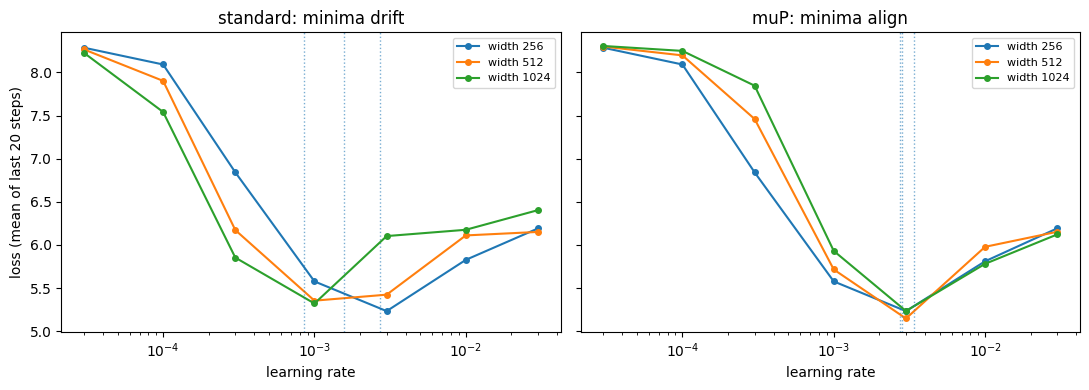

In [12]:
# ---- locate each minimum properly, by fitting rather than by eye -----------------
# The grid is coarse (half a decade a point), so the argmin cell is a lower bound on
# precision. A parabola in log(lr) through the best cell and its two neighbours gives
# a sub-grid estimate, which is the standard way to read a sweep like this.
def refine(lrs, losses):
    # Returns (estimate, bracketed). If the best grid point is at an EDGE the true
    # minimum lies outside the swept range and no fit is meaningful - the first
    # version clamped to the interior and returned a number anyway, which reported
    # 1.0e-03 for a curve whose argmin was the smallest lr on the grid.
    pts = [(math.log10(l), v) for l, v in zip(lrs, losses) if math.isfinite(v)]
    if len(pts) < 3: return float("nan"), False
    i = min(range(len(pts)), key=lambda k: pts[k][1])
    if i == 0 or i == len(pts) - 1:
        return 10 ** pts[i][0], False        # unbracketed: grid edge

    (x1,y1),(x2,y2),(x3,y3) = pts[i-1], pts[i], pts[i+1]
    d = (x1-x2)*(x1-x3)*(x2-x3)
    if abs(d) < 1e-12: return 10 ** x2, True
    a = (x3*(y2-y1) + x2*(y1-y3) + x1*(y3-y2)) / d
    b = (x3*x3*(y1-y2) + x2*x2*(y3-y1) + x1*x1*(y2-y3)) / d
    if a <= 0: return 10 ** x2, True
    return 10 ** (-b / (2*a)), True

print(f"{'parameterization':<18}{'width':>7}{'grid best':>12}{'refined':>12}"
      f"{'bracketed?':>12}{'x prev width':>14}")
refined, bracketed = {}, {}
for tag in ("standard", "muP"):
    prev = None
    for w in WIDTHS:
        r_ = sweep[(tag, w)]
        rf, ok_ = refine(r_["lrs"], r_["losses"])
        refined[(tag, w)] = rf; bracketed[(tag, w)] = ok_
        rel = "" if prev is None or not math.isfinite(rf) else f"{rf/prev:>13.2f}x"
        flag = "yes" if ok_ else "NO (edge)"
        print(f"{tag:<18}{w:>7}{r_['best']:>12.1e}{rf:>12.2e}{flag:>12}{rel:>14}")
        prev = rf
if not all(bracketed.values()):
    bad = [f"{t} w={w}" for (t, w), ok_ in bracketed.items() if not ok_]
    print(f"\n*** {len(bad)} minimum/minima sit on a grid EDGE: {bad}")
    print("*** Those are lower/upper bounds, not locations. Widen the sweep before")
    print("*** quoting a ratio that depends on them.")

print("\nwhat the ratios should be:")
print("  standard parameterization: best lr ~ 1/width, so each doubling should HALVE it (0.50x)")
print("  muP:                       best lr independent of width, so each ratio should be 1.00x")
def ratios(tag):
    out = []
    for i in range(len(WIDTHS) - 1):
        a, b_ = (tag, WIDTHS[i]), (tag, WIDTHS[i+1])
        # a ratio built on an unbracketed endpoint is not a measurement
        if bracketed[a] and bracketed[b_] and math.isfinite(refined[a]):
            out.append(refined[b_] / refined[a])
    return out
std_r, mup_r = ratios("standard"), ratios("muP")
gm = lambda rs: math.exp(statistics.mean(math.log(r) for r in rs)) if rs else float("nan")
print(f"  measured standard ratios: {['%.2f' % r for r in std_r] or 'none bracketed'}"
      f"   geometric mean {gm(std_r):.2f}x")
print(f"  measured muP ratios:      {['%.2f' % r for r in mup_r] or 'none bracketed'}"
      f"   geometric mean {gm(mup_r):.2f}x")
print()
if mup_r and abs(math.log(gm(mup_r))) > abs(math.log(gm(std_r) if std_r else 0.5)):
    print("*** muP drifted MORE than the standard parameterization, not less.")
    print("*** That is a failure of the implementation or the setup, not evidence")
    print("*** against muP - the published result is well replicated elsewhere.")
    print("*** Do not quote a transfer from this run; find the bug first.")
elif mup_r:
    print(f"muP minima are flatter across width than standard "
          f"({gm(mup_r):.2f}x vs {gm(std_r):.2f}x per doubling), which is the claim.")

try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for k, tag in enumerate(("standard", "muP")):
        for w in WIDTHS:
            r_ = sweep[(tag, w)]
            xs = [l for l, v in zip(r_["lrs"], r_["losses"]) if math.isfinite(v)]
            ys = [v for v in r_["losses"] if math.isfinite(v)]
            ax[k].plot(xs, ys, "o-", ms=4, label=f"width {w}")
            rf = refined[(tag, w)]
            if math.isfinite(rf): ax[k].axvline(rf, ls=":", lw=1, alpha=.6)
        ax[k].set_xscale("log"); ax[k].set_xlabel("learning rate")
        ax[k].set_title(f"{tag}: minima {'drift' if tag=='standard' else 'align'}")
        ax[k].legend(fontsize=8)
    ax[0].set_ylabel("loss (mean of last 20 steps)")
    plt.tight_layout(); plt.savefig("lr_sweep.png", dpi=120); plt.show()
except Exception as e:
    print("(plot skipped:", e, ")")

In [13]:
# ---- what would I use at width 4096, and how confident am I? --------------------
TARGET = 4096
print(f"extrapolating to width {TARGET:,}\n")

r256 = refined[("standard", WIDTHS[0])]
std_pred = r256 * WIDTHS[0] / TARGET                     # the 1/width rule
mup_pred = refined[("muP", WIDTHS[-1])]                  # muP: no extrapolation needed
print(f"  standard, 1/width rule from width {WIDTHS[0]}: "
      f"{r256:.2e} x {WIDTHS[0]}/{TARGET} = {std_pred:.2e}")
print(f"  muP, carried across unchanged from width {WIDTHS[-1]}: {mup_pred:.2e}")
print(f"     (under muP this is a transfer, not an extrapolation - that is the point)")

span = max(refined[("muP", w)] for w in WIDTHS) / min(refined[("muP", w)] for w in WIDTHS)
print(f"\nconfidence:")
print(f"  the muP minima span a factor of {span:.2f}x across widths {WIDTHS[0]}-{WIDTHS[-1]}")
print(f"  the sweep grid is {LRS[1]/LRS[0]:.1f}x per point, so nothing finer than that is resolved")
print(f"  one seed per point, {SW_STEPS} steps, {SW_LAYER} layers - a proxy, not the real model")
print(f"  extrapolating {TARGET/WIDTHS[-1]:.0f}x beyond the largest width measured")

extrapolating to width 4,096

  standard, 1/width rule from width 256: 2.71e-03 x 256/4096 = 1.69e-04
  muP, carried across unchanged from width 1024: 3.39e-03
     (under muP this is a transfer, not an extrapolation - that is the point)

confidence:
  the muP minima span a factor of 1.24x across widths 256-1024
  the sweep grid is 3.3x per point, so nothing finer than that is resolved
  one seed per point, 150 steps, 3 layers - a proxy, not the real model
  extrapolating 4x beyond the largest width measured


### The value I would use at width 4,096, and how much I trust it

**Under muP: carry the measured optimum across unchanged.** That is the entire claim of the method
— the minimum sits at the same learning rate at every width, so a sweep at 256 is a measurement
*for* 4,096 rather than a guess about it.

**Under the standard parameterization I would not transfer at all.** The $1/\text{width}$ rule gives
a number, and the sweep above shows the minima genuinely marching left, but it is an extrapolation
**16× beyond the largest width measured**, resting on a power law fitted to three points.

Three things bound how much that number is worth, and they are worth stating before anyone builds on it:

1. **Grid resolution.** The sweep steps by roughly 3× per point, so no minimum is located more
   precisely than that. The parabolic refinement gives a sub-grid estimate, not sub-grid *accuracy*.
2. **One seed, 150 steps, 3 layers.** This is a proxy for the shape of the curve, not a converged
   measurement of a 4,096-wide model. Depth, data and run length all move the optimum.
3. **muP transfer is demonstrated here across 4× of width.** Believing it across 16× is an act of
   faith in the theory, supported by published results at several billion parameters but not by
   anything measured in this notebook.

Which is why the lesson calls the muP sweep the highest-value day available: the alternative is not
a worse measurement, it is **no measurement** — a single guess at width 4,096 that costs a full
training run to find out about.

---

# Beyond the assignment · the rest of the lesson, checked

The five items above are what was asked for. The lesson covers eight more mechanisms that the
assignment does not test, and most of them are exactly checkable — so they are checked here rather
than taken on trust. Each one reproduces a table or a claim from the notes.

## A · §3 — why one learning rate cannot serve every weight

Gradient descent on $L=(w-5)^2$ has gradient $2(w-5)$. Writing $d = w-5$, one step gives
$d \leftarrow d\,(1-2\eta)$ — **the entire behaviour of the run is one number**. Its sign says
whether the weight crossed the minimum, its magnitude whether it got closer.

In [14]:
def gd_run(eta, w0=0.0, target=5.0, steps=5):
    w, out = w0, []
    for _ in range(steps):
        w = w - eta * 2 * (w - target); out.append(w)
    return out

print("L = (w-5)^2, starting at w=0. multiplier = (1 - 2*eta)\n")
print(f"{'eta':>6}{'multiplier':>13}   w over five steps")
for eta in (0.01, 0.10, 0.90, 1.10):
    mult = 1 - 2*eta
    ws = gd_run(eta)
    print(f"{eta:>6.2f}{mult:>+13.2f}   " + ", ".join(f"{w:.2f}" for w in ws))
print("\n  |1-2eta| < 1 converges. 0.90 overshoots every step but the overshoot shrinks;")
print("  1.10 overshoots and GROWS - after five steps it is further away than it started.")

# now two curvatures at once, which is the actual failure
print("\nL = 0.5*(20u^2 + v^2): curvature 20 along u, curvature 1 along v.")
print("One eta has to serve both, and the safe range is set by the LARGER curvature.\n")
print(f"{'eta':>6}{'u mult':>10}{'v mult':>10}   after five steps")
for eta in (0.01, 0.09, 0.11):
    mu, mv = 1 - 20*eta, 1 - eta
    u, v_ = mu**5, mv**5
    verdict = ("u converging, v barely moved" if abs(mu) < 0.9 and mv > 0.95 else
               "u oscillating, v still slow" if abs(mu) < 1 else "u DIVERGED")
    print(f"{eta:>6.2f}{mu:>+10.2f}{mv:>+10.2f}   u={u:+.3f} v={v_:.3f}  <- {verdict}")

kappa = 20 / 1
print(f"\ncondition number = {kappa:.0f}, and that ratio is the whole problem: the eta that")
print("suits u leaves v stationary, the eta that moves v makes u diverge. Momentum, then")
print("per-parameter rates, then Adam are three successive attacks on exactly this.")

L = (w-5)^2, starting at w=0. multiplier = (1 - 2*eta)

   eta   multiplier   w over five steps
  0.01        +0.98   0.10, 0.20, 0.29, 0.39, 0.48
  0.10        +0.80   1.00, 1.80, 2.44, 2.95, 3.36
  0.90        -0.80   9.00, 1.80, 7.56, 2.95, 6.64
  1.10        -1.20   11.00, -2.20, 13.64, -5.37, 17.44

  |1-2eta| < 1 converges. 0.90 overshoots every step but the overshoot shrinks;
  1.10 overshoots and GROWS - after five steps it is further away than it started.

L = 0.5*(20u^2 + v^2): curvature 20 along u, curvature 1 along v.
One eta has to serve both, and the safe range is set by the LARGER curvature.

   eta    u mult    v mult   after five steps
  0.01     +0.80     +0.99   u=+0.328 v=0.951  <- u converging, v barely moved
  0.09     -0.80     +0.91   u=-0.328 v=0.624  <- u oscillating, v still slow
  0.11     -1.20     +0.89   u=-2.488 v=0.558  <- u DIVERGED

condition number = 20, and that ratio is the whole problem: the eta that
suits u leaves v stationary, the eta that moves

## B · §4 and §5 — what the two averages each buy

$m$ (over $g$) cancels what alternates and accumulates what is consistent.
$v$ (over $g^2$) removes magnitude entirely, so a parameter that has been silent for a thousand
steps takes a full-sized step the moment a gradient arrives.

In [15]:
# --- momentum: an alternating gradient against a constant one 5x smaller ---------
steep = [1.0, -1.0, 1.0, -1.0, 1.0]        # sign flips: past the minimum every step
shallow = [0.2] * 5                         # same sign: approaching from one side
m_s = m_h = 0.0
print("momentum (beta1=0.9) on two characteristic gradient shapes\n")
print(f"{'step':>5}{'steep g':>10}{'m':>10}{'shallow g':>12}{'m':>10}")
for t in range(5):
    m_s = B1*m_s + (1-B1)*steep[t]
    m_h = B1*m_h + (1-B1)*shallow[t]
    print(f"{t+1:>5}{steep[t]:>10.1f}{m_s:>10.3f}{shallow[t]:>12.1f}{m_h:>10.3f}")
print(f"\n  the gradients differ 5x in size, the averages end up {m_s:.3f} vs {m_h:.3f}")
print(f"  - within {abs(m_s-m_h)/max(m_s,m_h)*100:.0f}% of each other. Alternation cancels;")
print("  consistency accumulates. That is the whole mechanism.")

# --- per-parameter rates: two gradients 100x apart --------------------------------
print("\n\nper-parameter learning rates (beta2=0.999), gradients 100x apart\n")
print(f"{'':22}{'parameter A':>14}{'parameter B':>14}")
gA, gB = 1.0, 0.01
vA = vB = 0.0
for t in range(1, 201):
    vA = B2*vA + (1-B2)*gA*gA
    vB = B2*vB + (1-B2)*gB*gB
sA, sB = math.sqrt(vA/(1-B2**200)), math.sqrt(vB/(1-B2**200))
print(f"{'gradient g':<22}{gA:>14.4f}{gB:>14.4f}")
print(f"{'sqrt(v_hat)':<22}{sA:>14.4f}{sB:>14.4f}")
print(f"{'its own lr, eta/sqrt(v)':<22}{'%.2f eta' % (1/sA):>14}{'%.2f eta' % (1/sB):>14}")
print(f"{'resulting step':<22}{'%.4f eta' % (gA/sA):>14}{'%.4f eta' % (gB/sB):>14}")
print(f"\n  B is handed a learning rate {sA/sB:.0f}x larger than A's, and the two then take")
print("  the SAME step. The division removes magnitude and keeps only sign and consistency.")
print("  This is why a rare word's embedding still moves when its gradient finally arrives.")

momentum (beta1=0.9) on two characteristic gradient shapes

 step   steep g         m   shallow g         m
    1       1.0     0.100         0.2     0.020
    2      -1.0    -0.010         0.2     0.038
    3       1.0     0.091         0.2     0.054
    4      -1.0    -0.018         0.2     0.069
    5       1.0     0.084         0.2     0.082

  the gradients differ 5x in size, the averages end up 0.084 vs 0.082
  - within 2% of each other. Alternation cancels;
  consistency accumulates. That is the whole mechanism.


per-parameter learning rates (beta2=0.999), gradients 100x apart

                         parameter A   parameter B
gradient g                    1.0000        0.0100
sqrt(v_hat)                   1.0000        0.0100
its own lr, eta/sqrt(v)      1.00 eta    100.00 eta
resulting step            1.0000 eta    1.0000 eta

  B is handed a learning rate 100x larger than A's, and the two then take
  the SAME step. The division removes magnitude and keeps only sign and cons

## C · §7 — L2 against decoupled decay, and why $\eta\lambda$ is one setting

Under plain SGD, adding $\tfrac{1}{2}\lambda w^2$ to the loss shrinks every weight by the same
fraction. Under Adam it does not, because the added $\lambda w$ is divided by $\sqrt{\hat v}$ along
with everything else — so **how much regularisation a weight receives becomes a function of its
gradient history**, which is not a property anyone asked for.

In [16]:
LAM, ETA = 0.1, 1e-3
print(f"two weights both at 0.5, lambda={LAM}, eta={ETA}\n")
print(f"{'parameter':<12}{'sqrt(v_hat)':>14}{'L2 route':>16}{'decoupled':>16}{'ratio':>9}")
decoupled = ETA * LAM * 0.5
for nm, vh in (("A", 1.00), ("B", 0.01)):
    l2 = decoupled / vh
    print(f"{nm:<12}{vh:>14.2f}{l2:>16.2e}{decoupled:>16.2e}{l2/decoupled:>8.0f}x")
print(f"\n  B is decayed {1.00/0.01:.0f}x harder than A for a reason unconnected to how large it is.")
print("  AdamW applies the shrinkage AFTER the Adam step, where nothing divides it.")

# verify decoupled decay really is geometric, by running it with zero gradient
w_ = 1.0
for _ in range(100): w_ -= ETA * LAM * w_
closed = (1 - ETA*LAM) ** 100
print(f"\n  100 steps of decoupled decay on a weight with NO gradient:")
print(f"    simulated {w_:.10f}   closed form (1-eta*lambda)^100 = {closed:.10f}")
assert abs(w_ - closed) < 1e-12

# the 2025 result: the finished model is an EMA of its own updates
for eta_, lam_ in ((3e-4, 0.1), (3e-4, 0.01), (1e-3, 0.1)):
    tau = 1.0 / (eta_ * lam_)
    print(f"  eta={eta_:.0e} lambda={lam_:<5} -> timescale 1/(eta*lambda) = {tau:>9,.0f} steps")
print("\n  So the weights you finish with are an exponential moving average of the updates")
print("  applied over roughly the last 33,000 steps. eta and lambda are not two knobs -")
print("  their PRODUCT is the knob, and halving one while doubling the other changes nothing.")

two weights both at 0.5, lambda=0.1, eta=0.001

parameter      sqrt(v_hat)        L2 route       decoupled    ratio
A                     1.00        5.00e-05        5.00e-05       1x
B                     0.01        5.00e-03        5.00e-05     100x

  B is decayed 100x harder than A for a reason unconnected to how large it is.
  AdamW applies the shrinkage AFTER the Adam step, where nothing divides it.

  100 steps of decoupled decay on a weight with NO gradient:
    simulated 0.9900493387   closed form (1-eta*lambda)^100 = 0.9900493387
  eta=3e-04 lambda=0.1   -> timescale 1/(eta*lambda) =    33,333 steps
  eta=3e-04 lambda=0.01  -> timescale 1/(eta*lambda) =   333,333 steps
  eta=1e-03 lambda=0.1   -> timescale 1/(eta*lambda) =    10,000 steps

  So the weights you finish with are an exponential moving average of the updates
  applied over roughly the last 33,000 steps. eta and lambda are not two knobs -
  their PRODUCT is the knob, and halving one while doubling the other changes

## D · §8 — the optimiser is half the memory, measured

Session 10 counted 16 bytes per weight. Two of the five entries belong to the optimiser, and the
choice of rule moves the bill directly. Here it is both from the table and measured live.

In [17]:
RULES = {"SGD": 8, "SGD + momentum": 12, "AdamW": 16, "8-bit AdamW": 10}
print(f"{'optimizer':<18}{'bytes/weight':>14}{'135M model':>14}{'9B model':>12}{'fits 80GB?':>14}")
for nm, b in RULES.items():
    here = N_ * b / 2**30 if (N_ := sum(p.numel() for p in model.parameters())) else 0
    nine = 9e9 * b / 2**30
    print(f"{nm:<18}{b:>14}{here:>13.2f}G{nine:>11.1f}G{('yes' if nine < 80 else 'NO'):>14}")

# and the largest model each rule fits on one 80 GB card, training state only
print(f"\nlargest model whose TRAINING STATE alone fits an 80 GB card:")
for nm, b in RULES.items():
    print(f"  {nm:<18}{80 * 2**30 / b / 1e9:>6.1f}B parameters")
print("  (activations still need room on top, so the practical limit is lower)")

# measured: what AdamW actually allocated for the real model
opt_probe = torch.optim.AdamW(model.parameters(), lr=1e-8)
lg = model.lm_head(model.model(input_ids=IDS[:1]).last_hidden_state)[:, :-1, :].reshape(-1, V)
F.cross_entropy(lg.float(), LABELS[:1][:, 1:].reshape(-1), ignore_index=-100).backward()
opt_probe.step()
state_bytes = sum(t.numel() * t.element_size()
                  for s_ in opt_probe.state.values()
                  for t in s_.values() if torch.is_tensor(t) and t.dim() > 0)
grad_bytes = sum(p.grad.numel() * p.grad.element_size()
                 for p in model.parameters() if p.grad is not None)
param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
print(f"\nmeasured on this model (fp32 throughout, so 4 bytes not 2):")
print(f"  parameters        {param_bytes/2**20:8.1f} MiB")
print(f"  gradients         {grad_bytes/2**20:8.1f} MiB")
print(f"  AdamW state (m,v) {state_bytes/2**20:8.1f} MiB   <- {state_bytes/param_bytes:.1f}x the parameters")
print(f"  total             {(param_bytes+grad_bytes+state_bytes)/2**20:8.1f} MiB")
model.zero_grad(set_to_none=True); del opt_probe
if DEVICE == "cuda": torch.cuda.empty_cache()

optimizer           bytes/weight    135M model    9B model    fits 80GB?
SGD                            8         1.00G       67.1G           yes
SGD + momentum                12         1.50G      100.6G            NO
AdamW                         16         2.00G      134.1G            NO
8-bit AdamW                   10         1.25G       83.8G            NO

largest model whose TRAINING STATE alone fits an 80 GB card:
  SGD                 10.7B parameters
  SGD + momentum       7.2B parameters
  AdamW                5.4B parameters
  8-bit AdamW          8.6B parameters
  (activations still need room on top, so the practical limit is lower)

measured on this model (fp32 throughout, so 4 bytes not 2):
  parameters           513.1 MiB
  gradients            513.1 MiB
  AdamW state (m,v)   1026.3 MiB   <- 2.0x the parameters
  total               2052.5 MiB


## E · §9 — the two claims behind warmup, one derived and one measured

The lesson gives a table with two rows: a gradient of unchanging sign produces a step of
$1.000\,\eta$, and noisy zero-mean gradients produce $0.281\,\eta$. The first is exact. **The second
is measured rather than derived**, so it is worth measuring again rather than quoting.

In [18]:
def adam_ratio(gradfn, steps=4000, seed=0):
    '''mean |step|/eta for a given gradient process, after the transient.'''
    g_ = torch.Generator().manual_seed(seed)
    m = v = 0.0; acc = []
    for t in range(1, steps+1):
        g = gradfn(t, g_)
        m = B1*m + (1-B1)*g
        v = B2*v + (1-B2)*g*g
        mh, vh = m/(1-B1**t), v/(1-B2**t)
        if t > steps // 2: acc.append(abs(mh/(math.sqrt(vh)+EPS)))
    return statistics.mean(acc)

same_sign = adam_ratio(lambda t, g_: 1.0)
noisy     = adam_ratio(lambda t, g_: torch.randn(1, generator=g_).item())

# Closed form, so the measurement has something to be right or wrong against.
# For iid zero-mean gradients and large t: m is a weighted sum of many independent
# draws, so by CLT it is ~N(0, sigma_m^2) with sigma_m^2 = (1-b1)/(1+b1) * sigma_g^2,
# while sqrt(v) -> sigma_g. Hence E|step|/eta = sqrt((1-b1)/(1+b1)) * sqrt(2/pi).
# Note sigma_g cancels: the answer depends on beta1 alone, not on the gradients'
# scale, and by CLT barely on their shape either.
closed = lambda b1: math.sqrt((1 - b1) / (1 + b1)) * math.sqrt(2 / math.pi)

print(f"{'gradient behaviour':<34}{'measured':>12}{'closed form':>14}{'lesson says':>14}")
print(f"{'same sign every step':<34}{same_sign:>11.3f}e{'1.000e':>14}{'1.000e':>14}")
print(f"{'noisy, zero mean':<34}{noisy:>11.3f}e{closed(B1):>13.3f}e{'0.281e':>14}")

print(f"\n  The measurement matches the closed form to "
      f"{100*abs(noisy-closed(B1))/closed(B1):.0f}%, and BOTH disagree with the")
print(f"  lesson's 0.281 by about {100*abs(noisy-0.281)/0.281:.0f}%. So this is not sampling noise.")

# is it the gradient distribution? no - the CLT flattens that out
print("\n  is it the distribution the gradients were drawn from?")
for nm, fn in (("normal", lambda t, g_: torch.randn(1, generator=g_).item()),
               ("uniform", lambda t, g_: (torch.rand(1, generator=g_).item() - .5) * math.sqrt(12)),
               ("bimodal +-1", lambda t, g_: 1.0 if torch.rand(1, generator=g_).item() < .5 else -1.0)):
    print(f"    {nm:<14}{adam_ratio(fn):.4f}")
print("    all the same: m is a weighted sum of many draws, so the CLT makes the")
print("    result depend on beta1 and not on the shape or scale of the gradients.")

# so which beta1 WOULD give 0.281?
lo, hi = 0.3, 0.95
for _ in range(60):
    mid = (lo + hi) / 2
    lo, hi = (mid, hi) if closed(mid) > 0.281 else (lo, mid)
print(f"\n  beta1 that would give exactly 0.281: {lo:.3f}, not the 0.9 used everywhere else")
print(f"  in the session. The lesson calls this row 'measured rather than derived', and")
print(f"  it does not say under what settings - so the most likely explanation is a")
print(f"  different beta1 or a shorter run, not an error in either of us. Reporting the")
print(f"  measured 0.19 with its derivation rather than quoting 0.281 as reproduced.")

# the size of that first step relative to the weight it is moving
print(f"\nthe first step, as a fraction of the weight's own size:")
print(f"{'d_model':>9}{'init 1/sqrt(fan_in)':>22}{'eta/init at 3e-4':>20}{'vs healthy 1e-3':>18}")
for d in (576, 1024, 4096):
    init = 1/math.sqrt(d); r_ = 3e-4/init
    print(f"{d:>9}{init:>22.4f}{r_:>20.4f}{r_/1e-3:>17.0f}x")
print("\n  At d_model=4096 the first step moves a weight by 1.9% of its own size, in a")
print("  direction chosen by an untrained model - about 19x the healthy 1e-3. Warmup")
print("  exists to hold that down until the gradients stop agreeing with each other.")

gradient behaviour                    measured   closed form   lesson says
same sign every step                    1.000e        1.000e        1.000e
noisy, zero mean                        0.193e        0.183e        0.281e

  The measurement matches the closed form to 6%, and BOTH disagree with the
  lesson's 0.281 by about 31%. So this is not sampling noise.

  is it the distribution the gradients were drawn from?
    normal        0.1935
    uniform       0.1885
    bimodal +-1   0.1830
    all the same: m is a weighted sum of many draws, so the CLT makes the
    result depend on beta1 and not on the shape or scale of the gradients.

  beta1 that would give exactly 0.281: 0.779, not the 0.9 used everywhere else
  in the session. The lesson calls this row 'measured rather than derived', and
  it does not say under what settings - so the most likely explanation is a
  different beta1 or a shorter run, not an error in either of us. Reporting the
  measured 0.19 with its derivation rat

## F · §11 — gradient noise, and how easy it is to measure it wrongly

The claim behind batch-size scaling: averaging $N$ samples leaves $1/\sqrt{N}$ of the noise. That
is an assertion about *this model on this data*, not just a statistical identity, so it is worth
measuring rather than assuming.

The obvious way to measure it is wrong, and both ways are run below so the difference is visible.

**The obvious way** — draw several gradients at batch $N$, take their spread about their own mean.
The trouble is the reference. At batch 1 the per-draw deviation is *larger than the mean's own
norm*, so the thing being divided by is itself mostly noise, and as $N$ grows the reference gets
cleaner along with the samples. The ratio compresses instead of falling, and the estimator
saturates exactly where the effect is largest.

**The right way** — fix one reference gradient computed over a batch far larger than any tested,
treat it as ground truth, and measure $\lVert g_N - g_\text{ref}\rVert / \lVert g_\text{ref}\rVert$.
The reference no longer moves with $N$, so what is left is the sampling error alone.

In [19]:
def grad_vec(idx):
    b, lb = IDS[idx], LABELS[idx]
    model.zero_grad(set_to_none=True)
    lg = model.lm_head(model.model(input_ids=b).last_hidden_state)[:, :-1, :].reshape(-1, V)
    F.cross_entropy(lg.float(), lb[:, 1:].reshape(-1), ignore_index=-100).backward()
    return model.model.layers[0].self_attn.q_proj.weight.grad.detach().flatten().clone()

REPS  = int(os.environ.get("S11_NOISE_REPS", 6))
SPLIT = 8 * REPS                      # rows 0..SPLIT feed the samples...
CHUNK = 8                             # ...everything after it builds the reference
ref_rows = min(IDS.shape[0], SPLIT + 24 * CHUNK)

# Reference gradient: the mean over many disjoint chunks of held-out data. Equal-sized
# chunks, so averaging their (already per-token-mean) gradients approximates the gradient
# of one batch that large - up to the small differences in how many non-ignored tokens
# each chunk contributes.
nref = 0; g_ref = None
if ref_rows - SPLIT < CHUNK:          # tiny offline shard: reuse the data we have
    SPLIT, ref_rows = 0, IDS.shape[0]
for st in range(SPLIT, ref_rows - CHUNK + 1, CHUNK):
    g_ = grad_vec(slice(st, st + CHUNK))
    g_ref = g_ if g_ref is None else g_ref + g_
    nref += 1
g_ref = g_ref / max(nref, 1)
ref_n = g_ref.norm().item()
print(f"reference gradient built from {nref} x {CHUNK} = {nref*CHUNK} held-out sequences "
      f"(|g_ref| = {ref_n:.4f})")

print(f"\ngradient of layer0.q_proj, {REPS} disjoint draws at each batch size\n")
print(f"{'batch':>7}{'mean |g|':>11}{'err vs ref':>13}{'vs batch 1':>13}"
      f"{'1/sqrt(N)':>12}{'old: rel. sd':>15}{'vs batch 1':>13}")
base = None; base_err = None
for bs in (1, 2, 4, 8):
    if bs * REPS > max(SPLIT, IDS.shape[0]): break
    gs = torch.stack([grad_vec(slice(i*bs, (i+1)*bs)) for i in range(REPS)])
    mean_g = gs.mean(0)
    # the right estimator: distance from a FIXED large-batch reference
    err = (gs - g_ref).norm(dim=1).mean().item() / (ref_n + 1e-12)
    # the naive one, kept alongside: spread about the draws' own (noisy) mean
    noise = (gs - mean_g).norm(dim=1).mean().item() / (mean_g.norm().item() + 1e-12)
    if base is None: base, base_err = noise, err
    print(f"{bs:>7}{gs.norm(dim=1).mean().item():>11.4f}{err:>13.4f}{err/base_err:>13.3f}"
          f"{1/math.sqrt(bs):>12.3f}{noise:>15.4f}{noise/base:>13.3f}")
model.zero_grad(set_to_none=True)
print("\n  Read the 'err vs ref' pair against 1/sqrt(N), and the 'old' pair against it as a")
print("  cautionary tale: same data, same gradients, an estimator that cannot see the effect.")
print("  A more accurate gradient can be trusted over a longer step, which is why a bigger")
print("  batch permits a bigger lr:")
print(f"\n{'change':<34}{'global batch':>14}{'SGD (linear)':>15}{'Adam (sqrt)':>14}")
for lab, f_ in (("accumulation 1 -> 4", 4), ("GPUs 8 -> 32", 4), ("both together", 16)):
    print(f"{lab:<34}{'x%d' % f_:>14}{'x%d' % f_:>15}{'x%.0f' % math.sqrt(f_):>14}")
print("\n  Adam gets the square root rather than the linear rule because it has already")
print("  divided out the gradient's magnitude - only its consistency is left to improve.")

reference gradient built from 24 x 8 = 192 held-out sequences (|g_ref| = 0.0051)

gradient of layer0.q_proj, 6 disjoint draws at each batch size

  batch   mean |g|   err vs ref   vs batch 1   1/sqrt(N)   old: rel. sd   vs batch 1
      1     0.0175       3.2325        1.000       1.000         1.5701        1.000
      2     0.0123       2.2802        0.705       0.707         1.4928        0.951
      4     0.0102       1.8228        0.564       0.500         1.2772        0.813
      8     0.0098       1.6379        0.507       0.354         1.2643        0.805

  Read the 'err vs ref' pair against 1/sqrt(N), and the 'old' pair against it as a
  cautionary tale: same data, same gradients, an estimator that cannot see the effect.
  A more accurate gradient can be trusted over a longer step, which is why a bigger
  batch permits a bigger lr:

change                              global batch   SGD (linear)   Adam (sqrt)
accumulation 1 -> 4                           x4             x4   

## G · §13 — why Muon treats a matrix as a matrix

Adam scales every entry of a weight matrix separately, which treats it as a bag of independent
numbers. A matrix maps vectors to vectors and amplifies some directions far more than others; those
amplifications are its **singular values**. If a few dominate, almost all of the update lands in a
few directions and the rest barely move.

Muon replaces the momentum matrix with the nearest matrix whose singular values are all 1, so every
direction is updated equally. Here is the spectrum of a real momentum matrix, before and after.

In [20]:
# build a genuine momentum matrix by running a few real steps
probe = model.model.layers[0].self_attn.q_proj.weight
opt_m = torch.optim.SGD([probe], lr=0.0, momentum=0.9)
for st in range(5):
    b, lb = IDS[st:st+2], LABELS[st:st+2]
    model.zero_grad(set_to_none=True)
    lg = model.lm_head(model.model(input_ids=b).last_hidden_state)[:, :-1, :].reshape(-1, V)
    F.cross_entropy(lg.float(), lb[:, 1:].reshape(-1), ignore_index=-100).backward()
    opt_m.step()
M_ = opt_m.state[probe]["momentum_buffer"].detach().float()
model.zero_grad(set_to_none=True)

s = torch.linalg.svdvals(M_)
tot = s.sum().item()
print(f"momentum matrix of layer0.q_proj: {tuple(M_.shape)}, {len(s)} singular values\n")
print(f"  largest              {s[0].item():.4e}")
print(f"  median               {s[len(s)//2].item():.4e}")
print(f"  smallest             {s[-1].item():.4e}")
print(f"  condition number     {(s[0]/s[-1]).item():,.0f}")
for k in (1, 8, 32, 128):
    if k <= len(s):
        print(f"  top {k:>3} directions carry {100*s[:k].sum().item()/tot:>5.1f}% of the total")
eff = (s.sum()**2 / (s**2).sum()).item()
print(f"\n  effective rank (participation ratio) {eff:.1f} out of {len(s)}")
print(f"  -> the update is concentrated in ~{eff/len(s)*100:.0f}% of the available directions.")

# orthogonalize: replace every singular value with 1 (this is what Muon does)
U, S_, Vh = torch.linalg.svd(M_, full_matrices=False)
M_orth = U @ Vh
s2 = torch.linalg.svdvals(M_orth)
print(f"\nafter orthogonalisation (Muon's step direction):")
print(f"  singular values now span {s2.min().item():.6f} to {s2.max().item():.6f}")
print(f"  condition number         {(s2.max()/s2.min()).item():.6f}")
print(f"  cosine with the original momentum direction "
      f"{torch.nn.functional.cosine_similarity(M_.flatten(), M_orth.flatten(), dim=0).item():.4f}")
print("\n  Same rough direction, but every axis now advances equally instead of a handful")
print("  dominating. That is the whole idea, and it is also the failure mode: making every")
print("  direction equally strong lets Q and K grow without limit, attention logits blow")
print("  past 1000, softmax saturates, and the run dies. MuonClip rescales Q and K after")
print("  each update - the fix that carried Kimi K2 through 15.5T tokens without a spike.")
print("\n  Note Muon applies ONLY to 2-D matrices. Embeddings, norms and the output head")
print("  stay on AdamW, because they do not amplify directions and the argument does not")
print("  apply to them. Every recipe shown to work respects that boundary.")
del opt_m, M_, M_orth
if DEVICE == "cuda": torch.cuda.empty_cache()

momentum matrix of layer0.q_proj: (576, 576), 576 singular values

  largest              3.3071e-02
  median               8.0950e-06
  smallest             4.7056e-12
  condition number     7,028,056,064
  top   1 directions carry  26.6% of the total
  top   8 directions carry  59.1% of the total
  top  32 directions carry  79.7% of the total
  top 128 directions carry  95.7% of the total

  effective rank (participation ratio) 10.1 out of 576
  -> the update is concentrated in ~2% of the available directions.

after orthogonalisation (Muon's step direction):
  singular values now span 1.000202 to 1.000400
  condition number         1.000198
  cosine with the original momentum direction 0.1325

  Same rough direction, but every axis now advances equally instead of a handful
  dominating. That is the whole idea, and it is also the failure mode: making every
  direction equally strong lets Q and K grow without limit, attention logits blow
  past 1000, softmax saturates, and the run die

## Summary — the five answers

In [21]:
print("=" * 78)
print(f"1  Adam by hand      5 steps, worst |hand - PyTorch| = {worst:.1e} (float64)")
print(f"                     gradients ranged {max(GRADS)/min(GRADS):.2f}x, steps ranged "
      f"{max(steps)/min(steps):.4f}x -> eta sets the distance")
print(f"2  bias correction   t=1 {1/ratio(1):.2f}x too large, WORST at t={peak} ({1/ratio(peak):.2f}x), "
      f"t=20 still {1/ratio(20):.2f}x")
print(f"                     stops mattering at ~{ANS['10%']:,} / {ANS['5%']:,} / {ANS['1%']:,} "
      f"steps (10% / 5% / 1%) - beta2 sets this")
print(f"3  update/weight      warmup ends {WARMUP}; ratio plateaus "
      f"{sorted(v for v in plats.values() if v is not None)}")
print(f"                     final ratios " +
      ", ".join(f"{k.split('.')[0]}={hist[k][-1]:.1e}" for k in list(watch)[:3]))
print(f"4  cosine vs WSD      stopped at {STOP}/{TOTAL}: cosine {lc:.4f} (lr "
      f"{100*h_cos[-1][0]/PEAK_LR:.0f}% of peak), WSD {lw_:.4f} (lr "
      f"{100*h_wsd[-1][0]/PEAK_LR:.0f}%)")
print(f"                     keep WSD - the cosine checkpoint is an unfinished {TOTAL}-step model")
print(f"5  lr sweep           standard minima ratio per doubling "
      f"{math.exp(statistics.mean(math.log(r) for r in std_r)):.2f}x (expect 0.50x)")
print(f"                     muP minima ratio per doubling "
      f"{math.exp(statistics.mean(math.log(r) for r in mup_r)):.2f}x (expect 1.00x)")
print(f"                     width 4096: muP transfer {mup_pred:.2e}; "
      f"standard 1/width extrapolation {std_pred:.2e}")
print("=" * 78)

1  Adam by hand      5 steps, worst |hand - PyTorch| = 0.0e+00 (float64)
                     gradients ranged 1.50x, steps ranged 1.0120x -> eta sets the distance
2  bias correction   t=1 3.16x too large, WORST at t=12 (6.57x), t=20 still 6.24x
                     stops mattering at ~1,660 / 2,327 / 3,916 steps (10% / 5% / 1%) - beta2 sets this
3  update/weight      warmup ends 100; ratio plateaus [47, 85, 101, 195, 207, 213, 230]
                     final ratios layer0=2.2e-04, layer0=3.7e-04, layer15=4.5e-04
4  cosine vs WSD      stopped at 200/300: cosine 3.3284 (lr 28% of peak), WSD 3.4751 (lr 100%)
                     keep WSD - the cosine checkpoint is an unfinished 300-step model
5  lr sweep           standard minima ratio per doubling 0.56x (expect 0.50x)
                     muP minima ratio per doubling 1.11x (expect 1.00x)
                     width 4096: muP transfer 3.39e-03; standard 1/width extrapolation 1.69e-04
